<div style="text-align:center;">

# Modelo: Random Forest Classifier
### *Clasificación de la Rotación de Empleados (IBM HR Analytics)*

---
**Universidad de Antioquia — Instituto de Matemáticas**  
*Analítica de Datos — Laboratorio 5*

</div>

---

## Contenido de este notebook

Este notebook desarrolla — de forma autocontenida — el ciclo completo de modelado para el algoritmo **Random Forest**:

| Punto del Lab 5 | Sección |
|:----------------|:--------|
| 3. Preparación de los Datos | §2–§3 |
| 4. Entrenamiento del modelo (línea base) | §4 |
| 5. Validación cruzada estratificada (k = 5) | §5 |
| 7. Ajuste de hiperparámetros (`RandomizedSearchCV`) | §6 |
| Comparación pre/post-tuning | §7 |
| Ajuste del umbral de decisión ($\tau$) | §8 |

### Descripción del algoritmo

**Random Forest** es un ensamble de árboles entrenados con **bootstrap aggregation (bagging)** y **sub-muestreo aleatorio de features** en cada split. La votación promedio reduce la varianza característica del árbol individual sin perder su capacidad para capturar relaciones no lineales e interacciones. Suele ser un **modelo de referencia muy competitivo** en datos tabulares.

### Tratamiento del desbalance

Se usa `class_weight="balanced"`, que reponderará la pérdida de manera idéntica al árbol individual; combinado con el promedio de 300 árboles produce un clasificador más estable.


---
## 1. Importación de librerías y configuración

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import time, json, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns

# Preprocesamiento y pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Modelo
from sklearn.ensemble import RandomForestClassifier

# Validación cruzada, búsqueda y métricas
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_validate, cross_val_predict,
                                     RandomizedSearchCV)
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve,
                             confusion_matrix, precision_recall_curve)

# Distribuciones de probabilidad para el RandomizedSearch
from scipy.stats import loguniform, randint, uniform

# ── Estilo visual unificado ──────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi"        : 120,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "axes.titleweight"  : "bold",
    "axes.titlesize"    : 12,
    "axes.labelsize"    : 10,
    "font.size"         : 10,
    "legend.frameon"    : False,
})

COLOR_YES, COLOR_NO = "#e74c3c", "#3498db"
COLOR_MODELO        = "#2ca02c"
COLOR_BASE          = "#bdc3c7"
COLOR_TUNED         = COLOR_MODELO

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


---
## 2. Carga y preparación del conjunto de datos

In [2]:
DATA_PATH = Path.cwd().parent.parent / "data" / "raw" / "dataset_clasificacion.csv"

df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.strip()

# ── Eliminamos columnas sin información (constantes / identificador) ─────
COLS_DESCARTAR = ["EmployeeCount", "EmployeeNumber", "Over18", "StandardHours"]
df = df.drop(columns=COLS_DESCARTAR)

print(f"Dimensiones tras descartar columnas inútiles: {df.shape}")
df.head(3)

Dimensiones tras descartar columnas inútiles: (1470, 31)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0


---
## 3. Preparación de los Datos

### 3.1 Separación de variables predictoras (X) y objetivo (y)

Se codifica el target de manera explícita: $\text{Yes} \mapsto 1,\ \text{No} \mapsto 0$, con la clase positiva siendo la **renuncia** (que es la que interesa detectar).


In [3]:
y = (df["Attrition"] == "Yes").astype(int)
X = df.drop(columns=["Attrition"])

print(f"X : {X.shape[0]:,} observaciones × {X.shape[1]} features")
print(f"y : binaria — Yes(1) = {y.sum()}  |  No(0) = {(y==0).sum()}")
print(f"    Proporción de la clase positiva: {y.mean()*100:.2f} %")

X : 1,470 observaciones × 30 features
y : binaria — Yes(1) = 237  |  No(0) = 1233
    Proporción de la clase positiva: 16.12 %


### 3.2 Identificación del tipo de variables

Se replican las decisiones tomadas en `0.Exploracion_Inicial.ipynb`:

| Grupo | Tratamiento |
|:---|:---|
| **Nominales** (7) | One-Hot Encoding con `drop="first"` |
| **Numéricas + Ordinales** (23) | Estandarización con `StandardScaler` |


In [4]:
COLS_NOMINALES = ["BusinessTravel", "Department", "EducationField",
                  "Gender", "JobRole", "MaritalStatus", "OverTime"]

COLS_NUMERICAS = [c for c in X.columns if c not in COLS_NOMINALES]

print(f"Nominales ({len(COLS_NOMINALES)}) : {COLS_NOMINALES}")
print(f"\nNuméricas ({len(COLS_NUMERICAS)}) : {COLS_NUMERICAS}")

Nominales (7) : ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Numéricas (23) : ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


### 3.3 Partición Train / Test estratificada

- Proporción **70 / 30** (entrenamiento / prueba).
- Se usa **estratificación por la variable objetivo** (`stratify=y`) para preservar la proporción $16.1\,/\,83.9$ en ambos subconjuntos.
- `random_state=42` para reproducibilidad.


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f"Train : {X_train.shape[0]:,} obs.  | Yes = {y_train.mean()*100:.2f} %")
print(f"Test  : {X_test.shape[0]:,} obs.  | Yes = {y_test.mean()*100:.2f} %")

Train : 1,029 obs.  | Yes = 16.13 %
Test  : 441 obs.  | Yes = 16.10 %


### 3.4 Construcción del Pipeline de preprocesamiento

El `ColumnTransformer` aplica **One-Hot Encoding** a las nominales y **estandarización** a las numéricas. Al estar **dentro del `Pipeline`**, ambas transformaciones son ajustadas únicamente sobre cada fold de entrenamiento durante la validación cruzada, evitando cualquier **fuga de información** desde los folds de validación.


In [6]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), COLS_NOMINALES),
        ("num", StandardScaler(), COLS_NUMERICAS),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

---
## 4. Modelo base (sin tuning)

Instanciamos primero el modelo con hiperparámetros por defecto + tratamiento del desbalance. Este modelo servirá como **línea base** contra la cual mediremos las mejoras del tuning.


In [7]:
modelo_base = Pipeline(steps=[
    ("preprocesamiento", preprocessor),
    ("clf", RandomForestClassifier(class_weight="balanced", n_estimators=300, random_state=42, n_jobs=-1)),
])

modelo_base.fit(X_train, y_train)
print("Modelo base entrenado.")

Modelo base entrenado.


---
## 5. Validación Cruzada del modelo base (k = 5)

### 5.1 Diseño del experimento

- **`StratifiedKFold`** con `n_splits=5`, `shuffle=True`, `random_state=42`.
- Cinco métricas: `accuracy`, `precision`, `recall`, `f1`, `roc_auc`.
- El `Pipeline` completo se reajusta en cada fold ⇒ no hay fuga de información.
- Resultados reportados como $\mu \pm \sigma$ sobre los 5 folds.


In [8]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

cv_base = cross_validate(modelo_base, X_train, y_train,
                         cv=skf, scoring=scoring,
                         return_train_score=True, n_jobs=-1)

print("Validación cruzada (modelo base) finalizada.")

Validación cruzada (modelo base) finalizada.


### 5.2 Resultados consolidados — $\mu \pm \sigma$

In [9]:
def tabla_cv(cv, metricas):
    filas = []
    for m in metricas:
        t, v = cv[f"train_{m}"], cv[f"test_{m}"]
        filas.append({
            "Métrica"           : m.upper(),
            "Train  Media"      : t.mean(),
            "Train  Desv."      : t.std(),
            "Validación  Media" : v.mean(),
            "Validación  Desv." : v.std(),
            "Gap (Train − Val)" : t.mean() - v.mean(),
        })
    return pd.DataFrame(filas).set_index("Métrica").round(4)

tabla_base = tabla_cv(cv_base, scoring)
tabla_base

,Train Media,Train Desv.,Validación Media,Validación Desv.,Gap (Train − Val)
Métrica,,,,,
ACCURACY,1.0,0.0,0.8591,0.0055,0.1409
PRECISION,1.0,0.0,0.8362,0.1404,0.1638
RECALL,1.0,0.0,0.1688,0.0415,0.8312
F1,1.0,0.0,0.2761,0.0528,0.7239
ROC_AUC,1.0,0.0,0.8026,0.0375,0.1974


In [10]:
# Reporte en formato Media ± Desv. (limpio para presentación)
print("─" * 60)
print(f"  {'Métrica':<12} {'Validación':>22}     {'Train':>20}")
print("─" * 60)
for m in scoring:
    v, t = cv_base[f"test_{m}"], cv_base[f"train_{m}"]
    print(f"  {m.upper():<12} {v.mean():>8.4f} ± {v.std():.4f}     {t.mean():>8.4f} ± {t.std():.4f}")
print("─" * 60)

────────────────────────────────────────────────────────────
  Métrica                  Validación                    Train
────────────────────────────────────────────────────────────
  ACCURACY       0.8591 ± 0.0055       1.0000 ± 0.0000
  PRECISION      0.8362 ± 0.1404       1.0000 ± 0.0000
  RECALL         0.1688 ± 0.0415       1.0000 ± 0.0000
  F1             0.2761 ± 0.0528       1.0000 ± 0.0000
  ROC_AUC        0.8026 ± 0.0375       1.0000 ± 0.0000
────────────────────────────────────────────────────────────


### 5.3 Distribución de las métricas por fold

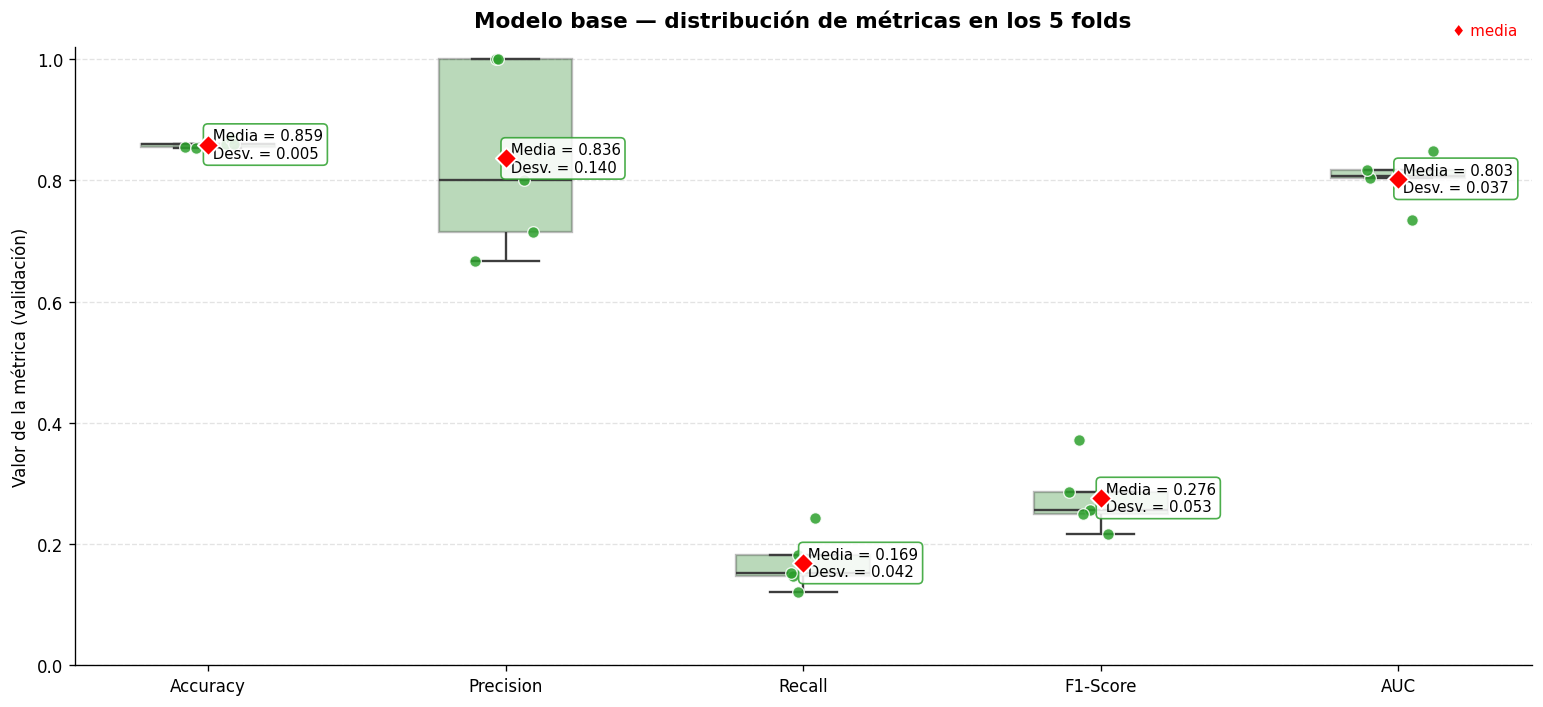

In [11]:
nombres = ["Accuracy", "Precision", "Recall", "F1-Score", "AUC"]

data_tidy = []
for m, nom in zip(scoring, nombres):
    for fold, val in enumerate(cv_base[f"test_{m}"], start=1):
        data_tidy.append({"Métrica": nom, "Fold": fold, "Valor": val})
df_tidy = pd.DataFrame(data_tidy)

fig, ax = plt.subplots(figsize=(13, 6))

sns.boxplot(data=df_tidy, x="Métrica", y="Valor",
            color=COLOR_MODELO, width=0.45, fliersize=0, ax=ax, linewidth=1.4,
            boxprops=dict(alpha=0.35))
sns.stripplot(data=df_tidy, x="Métrica", y="Valor",
              color=COLOR_MODELO, size=7, jitter=0.12, alpha=0.85,
              edgecolor="white", linewidth=0.8, ax=ax)

for i, m in enumerate(scoring):
    media = cv_base[f"test_{m}"].mean()
    std   = cv_base[f"test_{m}"].std()
    ax.text(i, media, f" Media = {media:.3f}\n Desv. = {std:.3f}",
            fontsize=9, ha="left", va="center",
            bbox=dict(boxstyle="round,pad=0.3",
                      facecolor="white", edgecolor=COLOR_MODELO, alpha=0.85))
    ax.scatter(i, media, color="red", s=80, zorder=5,
               marker="D", edgecolor="white", linewidth=1.2)

ax.set_ylim(0, 1.02)
ax.set_ylabel("Valor de la métrica (validación)")
ax.set_xlabel("")
ax.set_title("Modelo base — distribución de métricas en los 5 folds", fontsize=13, pad=12)
ax.grid(axis="y", ls="--", alpha=0.35)
ax.text(0.99, 1.02, "♦ media", transform=ax.transAxes, ha="right", fontsize=9, color="red")
plt.tight_layout()
plt.show()

### 5.4 Diagnóstico de sobreajuste — Train vs. Validación

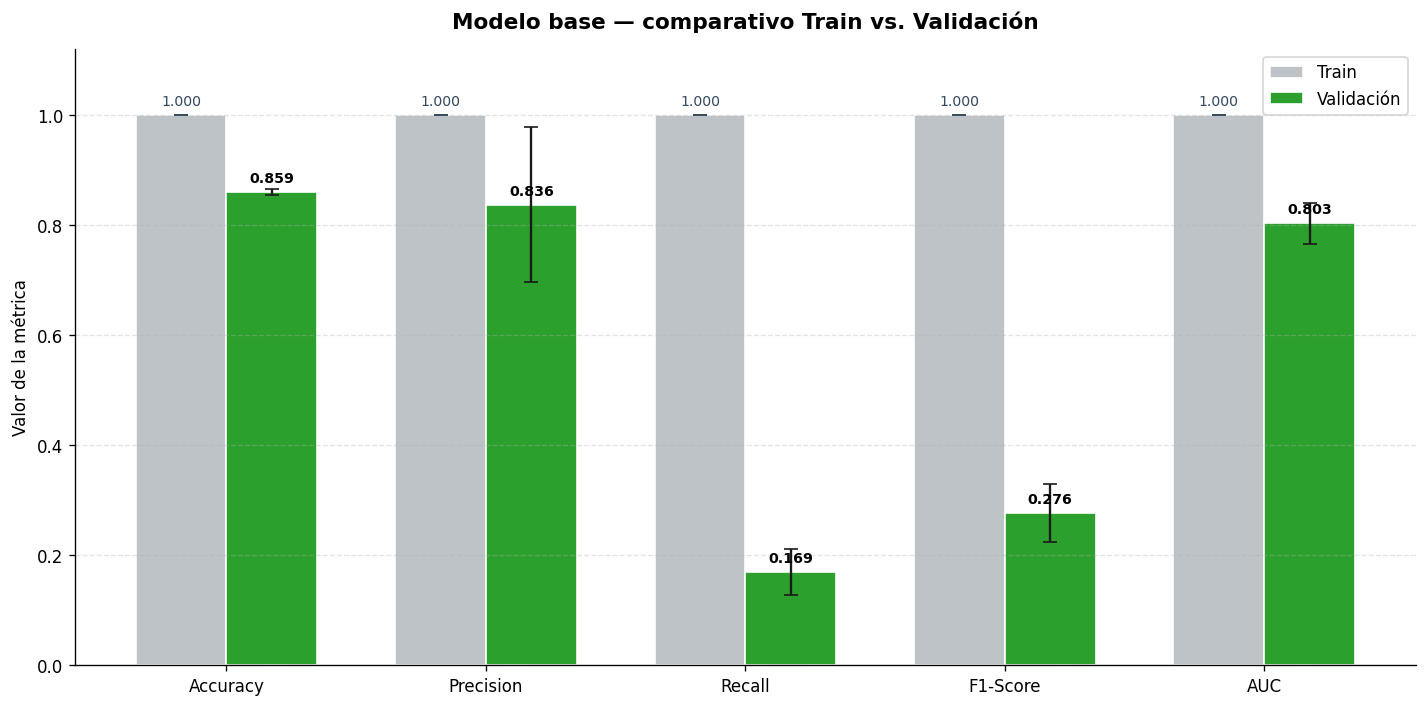

In [12]:
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(scoring))
ancho = 0.35
medias_t = [cv_base[f"train_{m}"].mean() for m in scoring]
stds_t   = [cv_base[f"train_{m}"].std()  for m in scoring]
medias_v = [cv_base[f"test_{m}"].mean()  for m in scoring]
stds_v   = [cv_base[f"test_{m}"].std()   for m in scoring]

bt = ax.bar(x - ancho/2, medias_t, ancho, yerr=stds_t, capsize=4,
            color="#bdc3c7", edgecolor="white", label="Train",
            error_kw=dict(elinewidth=1.4, ecolor="#34495e"))
bv = ax.bar(x + ancho/2, medias_v, ancho, yerr=stds_v, capsize=4,
            color=COLOR_MODELO, edgecolor="white", label="Validación",
            error_kw=dict(elinewidth=1.4, ecolor="#1a1a1a"))

for b, val in zip(bt, medias_t):
    ax.text(b.get_x() + b.get_width()/2, val + 0.018, f"{val:.3f}",
            ha="center", fontsize=8.5, color="#34495e")
for b, val in zip(bv, medias_v):
    ax.text(b.get_x() + b.get_width()/2, val + 0.018, f"{val:.3f}",
            ha="center", fontsize=8.5, fontweight="bold")

ax.set_xticks(x); ax.set_xticklabels(nombres)
ax.set_ylim(0, 1.12)
ax.set_ylabel("Valor de la métrica")
ax.set_title("Modelo base — comparativo Train vs. Validación", fontsize=13, pad=12)
ax.legend(loc="upper right", frameon=True, fancybox=True)
ax.grid(axis="y", ls="--", alpha=0.35)
plt.tight_layout()
plt.show()

### 5.5 Matriz de Confusión — predicciones out-of-fold

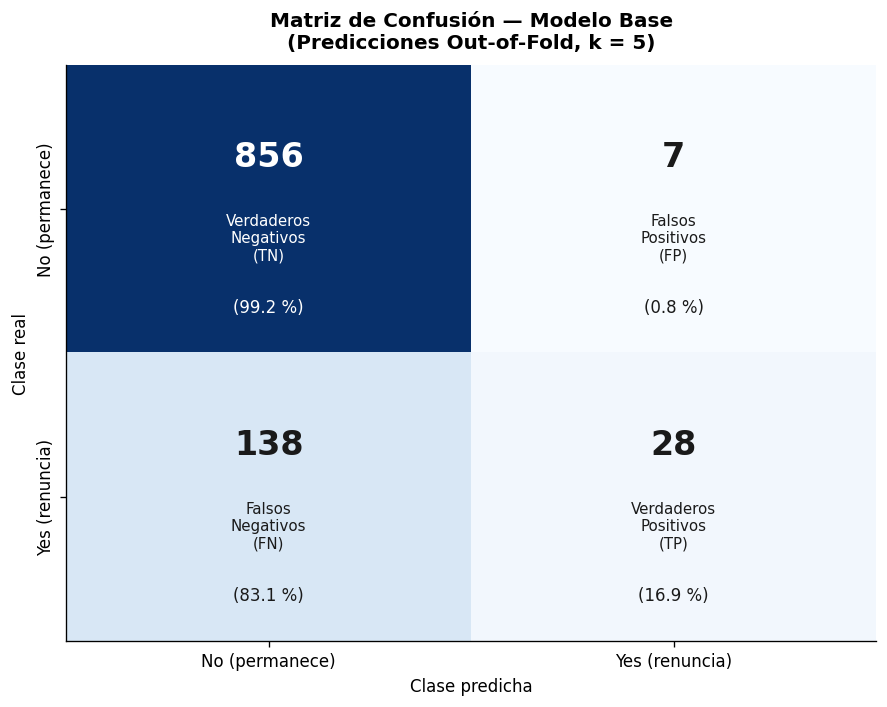


TN=856  FP=7  FN=138  TP=28
Recall  (de las renuncias reales, ¿cuántas detecto?)  = 0.1687
Precision (de mis alertas Yes, ¿cuántas son ciertas?) = 0.8000


In [13]:
# Predicciones out-of-fold (cada obs predicha por un modelo que NO la vio en su train)
y_pred_cv_base = cross_val_predict(modelo_base, X_train, y_train, cv=skf, n_jobs=-1)
cm_base = confusion_matrix(y_train, y_pred_cv_base, labels=[0, 1])

def plot_cm(cm, title, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6.5, 5.5))
    cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100
    im = ax.imshow(cm, cmap="Blues", aspect="auto")
    etiq = ["No (permanece)", "Yes (renuncia)"]
    desc = np.array([
        ["Verdaderos\nNegativos\n(TN)", "Falsos\nPositivos\n(FP)"],
        ["Falsos\nNegativos\n(FN)",      "Verdaderos\nPositivos\n(TP)"],
    ])
    for i in range(2):
        for j in range(2):
            v = cm[i, j]
            col = "white" if v > cm.max() * 0.55 else "#1a1a1a"
            ax.text(j, i - 0.18, f"{v:,}", ha="center", va="center",
                    color=col, fontsize=20, fontweight="bold")
            ax.text(j, i + 0.10, desc[i, j], ha="center", va="center",
                    color=col, fontsize=9)
            ax.text(j, i + 0.34, f"({cm_pct[i, j]:.1f} %)", ha="center", va="center",
                    color=col, fontsize=10)
    ax.set_xticks([0, 1]); ax.set_xticklabels(etiq, fontsize=10)
    ax.set_yticks([0, 1]); ax.set_yticklabels(etiq, fontsize=10, rotation=90, va="center")
    ax.set_xlabel("Clase predicha"); ax.set_ylabel("Clase real")
    ax.set_title(title, pad=10)
    return ax

fig, ax = plt.subplots(figsize=(7.5, 6))
plot_cm(cm_base, "Matriz de Confusión — Modelo Base\n(Predicciones Out-of-Fold, k = 5)", ax=ax)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_base.ravel()
print(f"\nTN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}")
print(f"Recall  (de las renuncias reales, ¿cuántas detecto?)  = {tp/(tp+fn):.4f}")
print(f"Precision (de mis alertas Yes, ¿cuántas son ciertas?) = {tp/(tp+fp) if (tp+fp)>0 else 0:.4f}")

---
## 6. Ajuste de Hiperparámetros — `RandomizedSearchCV`

### 6.1 Estrategia de búsqueda

- **Algoritmo**: `RandomizedSearchCV` con `n_iter=60` candidatos aleatorios.
- **Validación**: el mismo `StratifiedKFold(n_splits=5)` usado en §5 — comparabilidad directa.
- **Métrica a optimizar**: **`f1`**. Justificación: en el problema de Attrition queremos **detectar renuncias (alto Recall) sin generar demasiados falsos positivos (Precision razonable)**. El F1, al ser la media armónica de ambos, premia exactamente ese equilibrio.
- **Espacio de búsqueda** (definido abajo): cubre las palancas de **regularización** (para corregir el sobreajuste detectado) y de **manejo del desbalance** (para mover el tradeoff Precision-Recall).

### 6.2 Hiperparámetros explorados

- **`n_estimators`** — número de árboles en el bosque. Más árboles → menos varianza, pero rendimientos decrecientes y más costo computacional.
- **`max_depth`** — limita el crecimiento de cada árbol (la regularización clave).
- **`min_samples_leaf`** — mínimo de observaciones por hoja en cada árbol.
- **`max_features`** — features candidatas por split (`sqrt(p)` es el default y suele ser óptimo en clasificación).
- **`bootstrap`** — si los árboles usan muestreo con reemplazo (bagging clásico). `False` desactiva el bagging.
- **`class_weight`** — `"balanced_subsample"` recomputa los pesos en cada bootstrap.


In [14]:
param_dist = {
    "clf__n_estimators"     : randint(100, 500),                       # número de árboles
    "clf__max_depth"        : randint(5, 30),                          # profundidad máxima
    "clf__min_samples_split": randint(2, 20),
    "clf__min_samples_leaf" : randint(1, 10),
    "clf__max_features"     : ["sqrt", "log2"],
    "clf__bootstrap"        : [True, False],
    "clf__class_weight"     : ["balanced", "balanced_subsample"],
}

print("Espacio de búsqueda definido:")
for k in param_dist:
    print(f"  · {k}")

Espacio de búsqueda definido:
  · clf__n_estimators
  · clf__max_depth
  · clf__min_samples_split
  · clf__min_samples_leaf
  · clf__max_features
  · clf__bootstrap
  · clf__class_weight


### 6.3 Ejecución del search

> Esta celda puede tardar entre 30 segundos y varios minutos según el modelo. Se reentrenan $60 \times 5 = 300$ pipelines completos.


In [15]:
t0 = time.time()
search = RandomizedSearchCV(
    estimator           = modelo_base,        # mismo pipeline base
    param_distributions = param_dist,
    n_iter              = 60,
    cv                  = skf,
    scoring             = "f1",
    return_train_score  = True,
    random_state        = 42,
    n_jobs              = -1,
    refit               = True,
    verbose             = 0,
)
search.fit(X_train, y_train)
print(f"Búsqueda completada en {time.time()-t0:.1f}s")
print(f"Mejor F1 (validación CV): {search.best_score_:.4f}")
print(f"\nMejores hiperparámetros:")
for k, v in search.best_params_.items():
    print(f"  · {k.replace('clf__',''):<22s} = {v}")

Búsqueda completada en 206.8s
Mejor F1 (validación CV): 0.5259

Mejores hiperparámetros:
  · bootstrap              = False
  · class_weight           = balanced
  · max_depth              = 16
  · max_features           = log2
  · min_samples_leaf       = 8
  · min_samples_split      = 12
  · n_estimators           = 180


### 6.4 Análisis del search — distribución del F1 sobre las 60 configuraciones

Cada punto representa una configuración aleatoria evaluada. Permite ver la **dispersión total** del desempeño, dónde cae el mejor y cuán por encima del modelo base estamos.


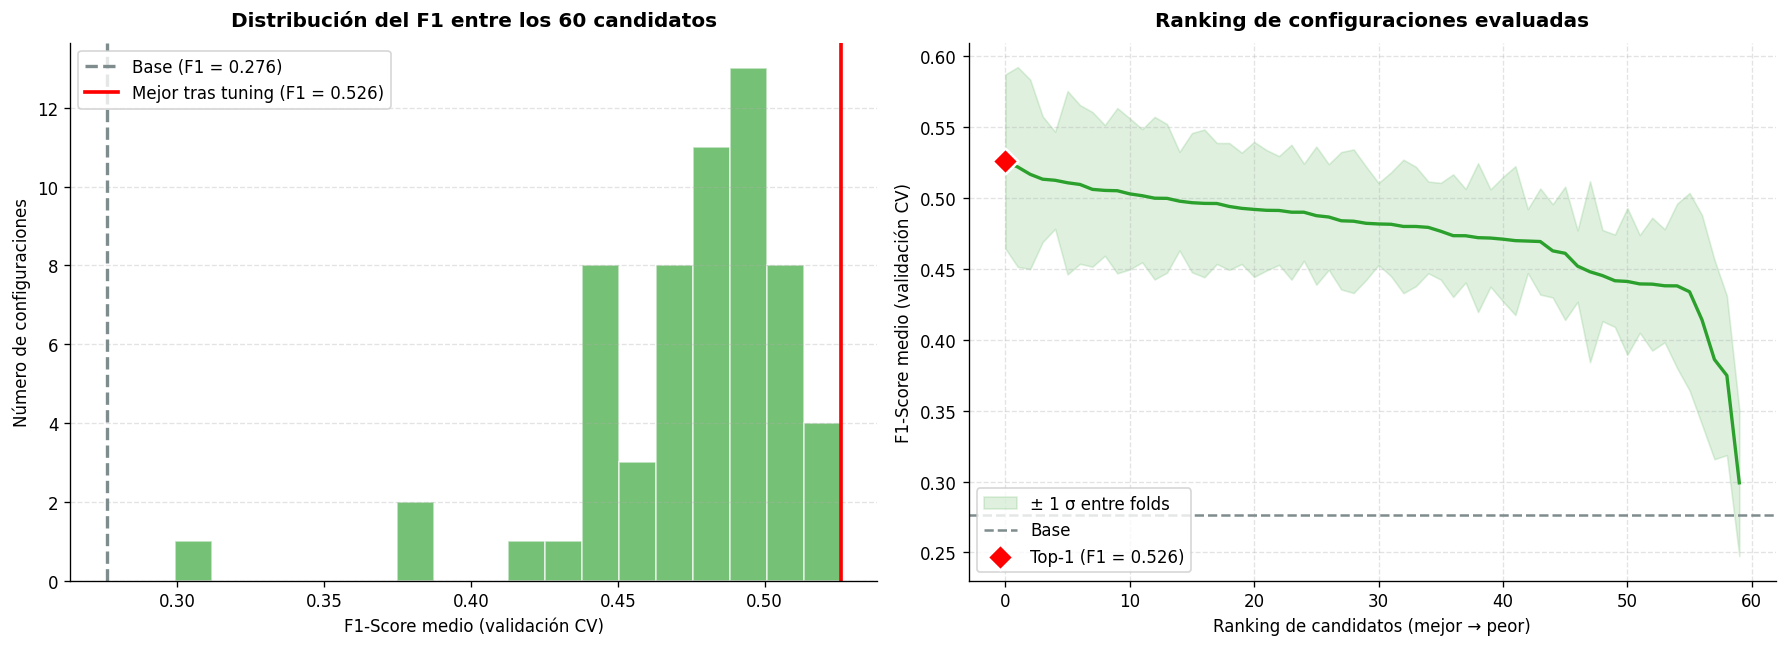

In [16]:
cv_df = pd.DataFrame(search.cv_results_)
cv_df_sorted = cv_df.sort_values("mean_test_score", ascending=False).reset_index(drop=True)

best_idx  = cv_df["mean_test_score"].idxmax()
f1_base   = cv_base["test_f1"].mean()

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# ── Panel A: histograma + KDE de los 60 scores ───────────────────────────
ax = axes[0]
ax.hist(cv_df["mean_test_score"], bins=18, color=COLOR_MODELO,
        edgecolor="white", alpha=0.65)
ax.axvline(f1_base, color="#7f8c8d", ls="--", lw=2,
           label=f"Base (F1 = {f1_base:.3f})")
ax.axvline(search.best_score_, color="red", lw=2.2,
           label=f"Mejor tras tuning (F1 = {search.best_score_:.3f})")
ax.set_xlabel("F1-Score medio (validación CV)")
ax.set_ylabel("Número de configuraciones")
ax.set_title("Distribución del F1 entre los 60 candidatos", fontsize=12, pad=10)
ax.legend(loc="upper left", frameon=True, fancybox=True)
ax.grid(axis="y", ls="--", alpha=0.35)

# ── Panel B: ranking ordenado de los 60 ─────────────────────────────────
ax = axes[1]
xs = np.arange(len(cv_df_sorted))
ax.plot(xs, cv_df_sorted["mean_test_score"].values, color=COLOR_MODELO, lw=2)
ax.fill_between(xs,
                cv_df_sorted["mean_test_score"] - cv_df_sorted["std_test_score"],
                cv_df_sorted["mean_test_score"] + cv_df_sorted["std_test_score"],
                color=COLOR_MODELO, alpha=0.15, label="± 1 σ entre folds")
ax.axhline(f1_base, color="#7f8c8d", ls="--", lw=1.5, label="Base")
ax.scatter([0], [cv_df_sorted["mean_test_score"].iloc[0]],
           s=120, color="red", zorder=5, marker="D",
           edgecolor="white", linewidth=1.5,
           label=f"Top-1 (F1 = {cv_df_sorted['mean_test_score'].iloc[0]:.3f})")
ax.set_xlabel("Ranking de candidatos (mejor → peor)")
ax.set_ylabel("F1-Score medio (validación CV)")
ax.set_title("Ranking de configuraciones evaluadas", fontsize=12, pad=10)
ax.legend(loc="lower left", frameon=True, fancybox=True)
ax.grid(ls="--", alpha=0.35)

plt.tight_layout()
plt.show()

### 6.5 Efecto de los hiperparámetros clave

Para los hiperparámetros más influyentes (`n_estimators`, `max_depth`, `min_samples_leaf`), graficamos el F1 de validación contra el valor del hiperparámetro. Permite ver **qué rangos producen los mejores modelos** y si hay zonas claramente malas.


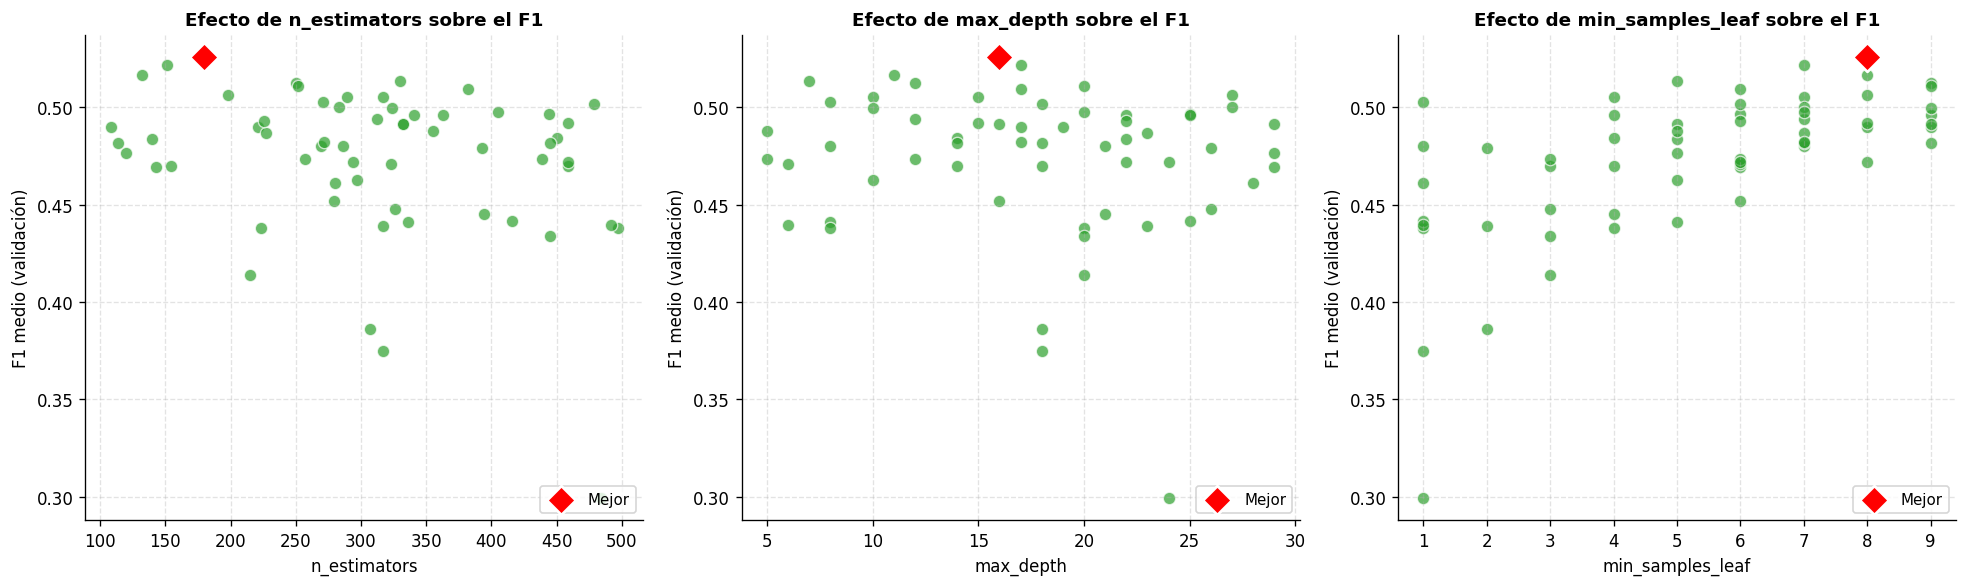

In [17]:
hp_destacar = ['clf__n_estimators', 'clf__max_depth', 'clf__min_samples_leaf']

fig, axes = plt.subplots(1, len(hp_destacar), figsize=(5.5 * len(hp_destacar), 5))
if len(hp_destacar) == 1:
    axes = [axes]

for ax, hp in zip(axes, hp_destacar):
    col = f"param_{hp}"
    if col not in cv_df.columns:
        ax.set_visible(False); continue
    valores = cv_df[col].astype(str)  # categórico
    scores  = cv_df["mean_test_score"]

    # ¿Es numérico?
    try:
        valores_num = cv_df[col].astype(float)
        ax.scatter(valores_num, scores, color=COLOR_MODELO, alpha=0.7,
                   s=55, edgecolor="white", linewidth=0.8)
        # destaca el mejor
        ax.scatter(float(cv_df.loc[best_idx, col]), search.best_score_,
                   color="red", s=150, marker="D", edgecolor="white",
                   linewidth=1.6, zorder=5, label="Mejor")
        # tendencia loess simple
        ax.set_xlabel(hp.replace("clf__", ""))
    except (ValueError, TypeError):
        # categórico: boxplot
        df_box = pd.DataFrame({"valor": valores, "score": scores})
        sns.boxplot(data=df_box, x="valor", y="score", ax=ax,
                    color=COLOR_MODELO, width=0.45, fliersize=0,
                    boxprops=dict(alpha=0.4))
        sns.stripplot(data=df_box, x="valor", y="score", ax=ax,
                      color=COLOR_MODELO, size=5.5, alpha=0.85,
                      edgecolor="white", linewidth=0.6)
        mejor_val = str(cv_df.loc[best_idx, col])
        try:
            posicion = list(df_box["valor"].unique()).index(mejor_val)
            ax.scatter(posicion, search.best_score_, color="red",
                       s=150, marker="D", edgecolor="white",
                       linewidth=1.6, zorder=5, label="Mejor")
        except ValueError:
            pass
        ax.set_xlabel(hp.replace("clf__", ""))
        ax.tick_params(axis="x", rotation=20)

    ax.set_ylabel("F1 medio (validación)")
    ax.set_title(f"Efecto de {hp.replace('clf__','')} sobre el F1", fontsize=11)
    ax.grid(ls="--", alpha=0.35)
    ax.legend(loc="lower right", frameon=True, fontsize=9)

plt.tight_layout()
plt.show()

### 6.6 Top-10 configuraciones y su perfil de hiperparámetros


In [18]:
cols_param = [c for c in cv_df.columns if c.startswith("param_")]
cols_show  = cols_param + ["mean_test_score", "std_test_score", "mean_train_score"]

top10 = (cv_df.sort_values("mean_test_score", ascending=False)
              .head(10)
              .reset_index(drop=True)
              [cols_show]
              .rename(columns=lambda c: c.replace("param_clf__","").replace("mean_test_score","F1 Val μ")
                                          .replace("std_test_score","F1 Val σ")
                                          .replace("mean_train_score","F1 Train μ")))

# Redondeamos columnas numéricas
for c in top10.columns:
    if pd.api.types.is_numeric_dtype(top10[c]):
        top10[c] = top10[c].round(4)

top10

,bootstrap,class_weight,max_depth,max_features,min_samples_leaf,min_samples_split,n_estimators,F1 Val μ,F1 Val σ,F1 Train μ
0,False,balanced,16,log2,8,12,180,0.5259,0.0614,0.9085
1,False,balanced_subsample,17,sqrt,7,18,151,0.5220,0.0705,0.9203
2,False,balanced,11,sqrt,8,13,132,0.5168,0.0668,0.9078
3,False,balanced,7,sqrt,5,11,330,0.5134,0.0443,0.9225
4,True,balanced_subsample,12,sqrt,9,19,250,0.5126,0.0343,0.8164
5,False,balanced,20,log2,9,4,252,0.5109,0.0647,0.8970
6,False,balanced_subsample,17,sqrt,6,9,382,0.5097,0.0560,0.9466
7,False,balanced,27,log2,8,6,198,0.5062,0.0546,0.9091
8,False,balanced_subsample,10,log2,4,19,317,0.5055,0.0461,0.9268
9,False,balanced_subsample,15,log2,7,8,289,0.5052,0.0583,0.9255


---
## 7. Comparativo Base vs. Tuned (validación cruzada)

Re-evaluamos el **mejor modelo** encontrado con el mismo protocolo de CV usado para el modelo base. Esto permite una comparación honesta.


In [19]:
modelo_tuned = search.best_estimator_

cv_tuned = cross_validate(modelo_tuned, X_train, y_train,
                          cv=skf, scoring=scoring,
                          return_train_score=True, n_jobs=-1)

tabla_tuned = tabla_cv(cv_tuned, scoring)
print("Validación cruzada del modelo ajustado finalizada.")
tabla_tuned

Validación cruzada del modelo ajustado finalizada.


,Train Media,Train Desv.,Validación Media,Validación Desv.,Gap (Train − Val)
Métrica,,,,,
ACCURACY,0.9674,0.0044,0.8542,0.0206,0.1132
PRECISION,0.8325,0.0186,0.5568,0.0778,0.2757
RECALL,1.0000,0.0000,0.5000,0.0559,0.5000
F1,0.9085,0.0111,0.5259,0.0614,0.3826
ROC_AUC,0.9969,0.0003,0.7956,0.0373,0.2014


In [20]:
# Tabla comparativa Base vs Tuned
resumen = pd.DataFrame({
    "Métrica"        : [m.upper() for m in scoring],
    "Base (Media)"   : [cv_base[f"test_{m}"].mean()  for m in scoring],
    "Base (Desv.)"   : [cv_base[f"test_{m}"].std()   for m in scoring],
    "Tuned (Media)"  : [cv_tuned[f"test_{m}"].mean() for m in scoring],
    "Tuned (Desv.)"  : [cv_tuned[f"test_{m}"].std()  for m in scoring],
})
resumen["Δ Media"]   = (resumen["Tuned (Media)"] - resumen["Base (Media)"]).round(4)
resumen["Mejora %"]  = ((resumen["Tuned (Media)"] - resumen["Base (Media)"]) / resumen["Base (Media)"] * 100).round(2)
resumen = resumen.set_index("Métrica").round(4)
resumen

,Base (Media),Base (Desv.),Tuned (Media),Tuned (Desv.),Δ Media,Mejora %
Métrica,,,,,,
ACCURACY,0.8591,0.0055,0.8542,0.0206,-0.0049,-0.57
PRECISION,0.8362,0.1404,0.5568,0.0778,-0.2794,-33.41
RECALL,0.1688,0.0415,0.5000,0.0559,0.3312,196.20
F1,0.2761,0.0528,0.5259,0.0614,0.2498,90.48
ROC_AUC,0.8026,0.0375,0.7956,0.0373,-0.0070,-0.88


### 7.1 Visualización Base vs. Tuned

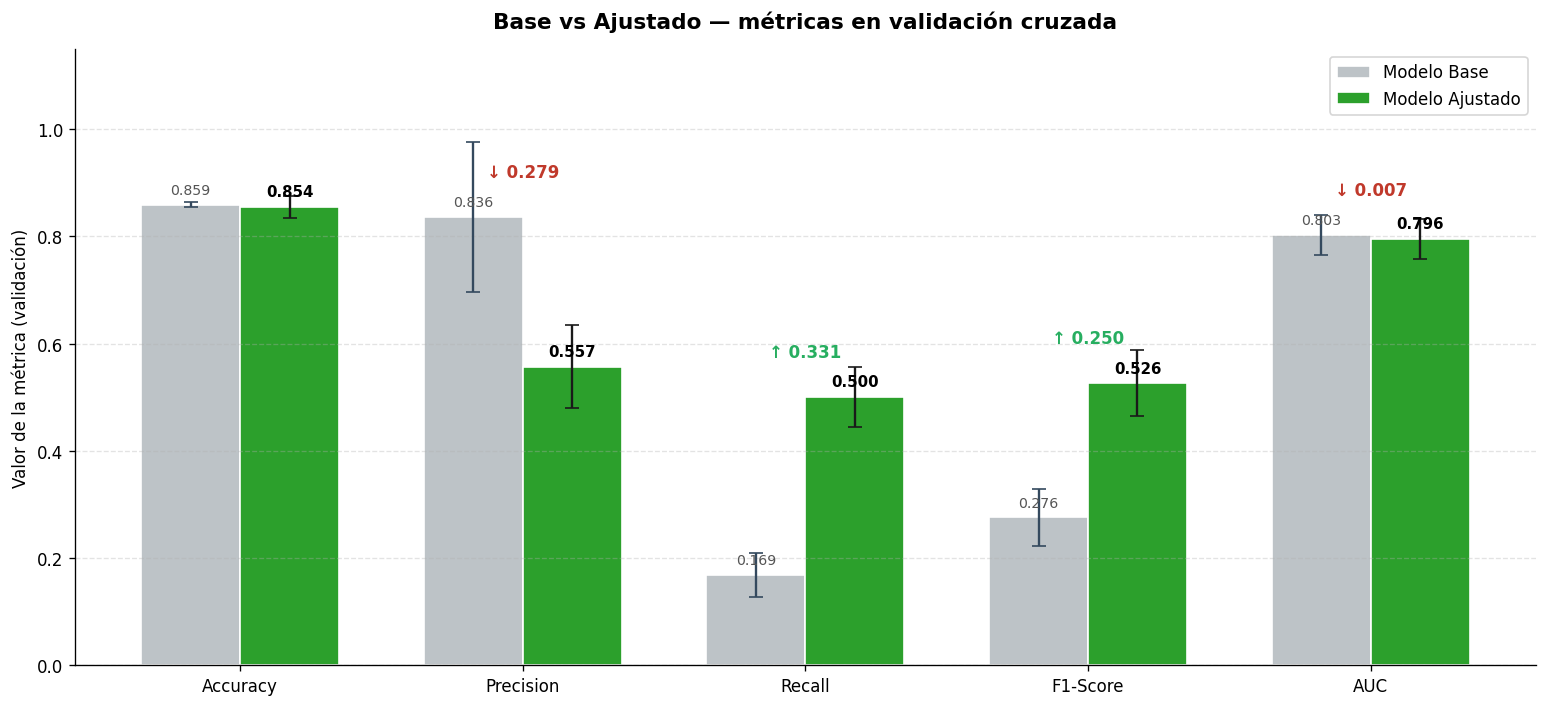

In [21]:
fig, ax = plt.subplots(figsize=(13, 6))

x = np.arange(len(scoring))
ancho = 0.35
m_base  = [cv_base[f"test_{m}"].mean()  for m in scoring]
s_base  = [cv_base[f"test_{m}"].std()   for m in scoring]
m_tuned = [cv_tuned[f"test_{m}"].mean() for m in scoring]
s_tuned = [cv_tuned[f"test_{m}"].std()  for m in scoring]

bb = ax.bar(x - ancho/2, m_base, ancho, yerr=s_base, capsize=4,
            color=COLOR_BASE, edgecolor="white", label="Modelo Base",
            error_kw=dict(elinewidth=1.4, ecolor="#34495e"))
bt = ax.bar(x + ancho/2, m_tuned, ancho, yerr=s_tuned, capsize=4,
            color=COLOR_TUNED, edgecolor="white", label="Modelo Ajustado",
            error_kw=dict(elinewidth=1.4, ecolor="#1a1a1a"))

for b, v in zip(bb, m_base):
    ax.text(b.get_x() + b.get_width()/2, v + 0.020, f"{v:.3f}",
            ha="center", fontsize=8.5, color="#555")
for b, v in zip(bt, m_tuned):
    ax.text(b.get_x() + b.get_width()/2, v + 0.020, f"{v:.3f}",
            ha="center", fontsize=9, fontweight="bold")

# Flechitas indicando dirección del cambio
for i in range(len(scoring)):
    delta = m_tuned[i] - m_base[i]
    if abs(delta) > 0.005:
        signo = "↑" if delta > 0 else "↓"
        color = "#27ae60" if delta > 0 else "#c0392b"
        ax.text(i, max(m_base[i], m_tuned[i]) + 0.075,
                f"{signo} {abs(delta):.3f}", ha="center",
                color=color, fontweight="bold", fontsize=10)

ax.set_xticks(x); ax.set_xticklabels(nombres)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Valor de la métrica (validación)")
ax.set_title("Base vs Ajustado — métricas en validación cruzada", fontsize=13, pad=12)
ax.legend(loc="upper right", frameon=True, fancybox=True)
ax.grid(axis="y", ls="--", alpha=0.35)
plt.tight_layout()
plt.show()

### 7.2 Reducción del sobreajuste (gap Train − Validación)

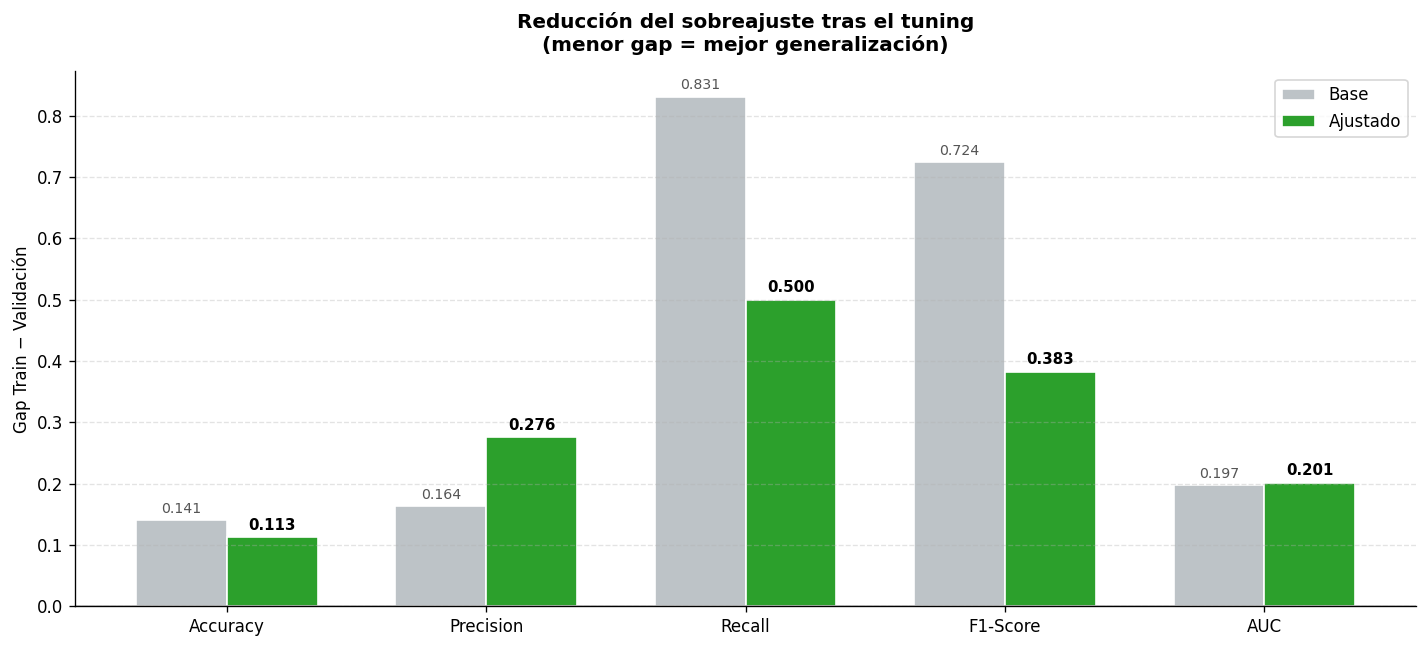

In [22]:
gap_base  = [cv_base[f"train_{m}"].mean()  - cv_base[f"test_{m}"].mean()  for m in scoring]
gap_tuned = [cv_tuned[f"train_{m}"].mean() - cv_tuned[f"test_{m}"].mean() for m in scoring]

fig, ax = plt.subplots(figsize=(12, 5.5))
x = np.arange(len(scoring)); ancho = 0.35

bb = ax.bar(x - ancho/2, gap_base, ancho, color=COLOR_BASE,
            edgecolor="white", label="Base")
bt = ax.bar(x + ancho/2, gap_tuned, ancho, color=COLOR_TUNED,
            edgecolor="white", label="Ajustado")

for b, v in zip(bb, gap_base):
    ax.text(b.get_x()+b.get_width()/2, v + 0.012,
            f"{v:.3f}", ha="center", fontsize=8.5, color="#555")
for b, v in zip(bt, gap_tuned):
    ax.text(b.get_x()+b.get_width()/2, v + 0.012,
            f"{v:.3f}", ha="center", fontsize=9, fontweight="bold")

ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(nombres)
ax.set_ylabel("Gap Train − Validación")
ax.set_title("Reducción del sobreajuste tras el tuning\n(menor gap = mejor generalización)",
             fontsize=12, pad=12)
ax.legend(loc="upper right", frameon=True, fancybox=True)
ax.grid(axis="y", ls="--", alpha=0.35)
plt.tight_layout()
plt.show()

### 7.3 Curvas ROC — Base vs. Ajustado

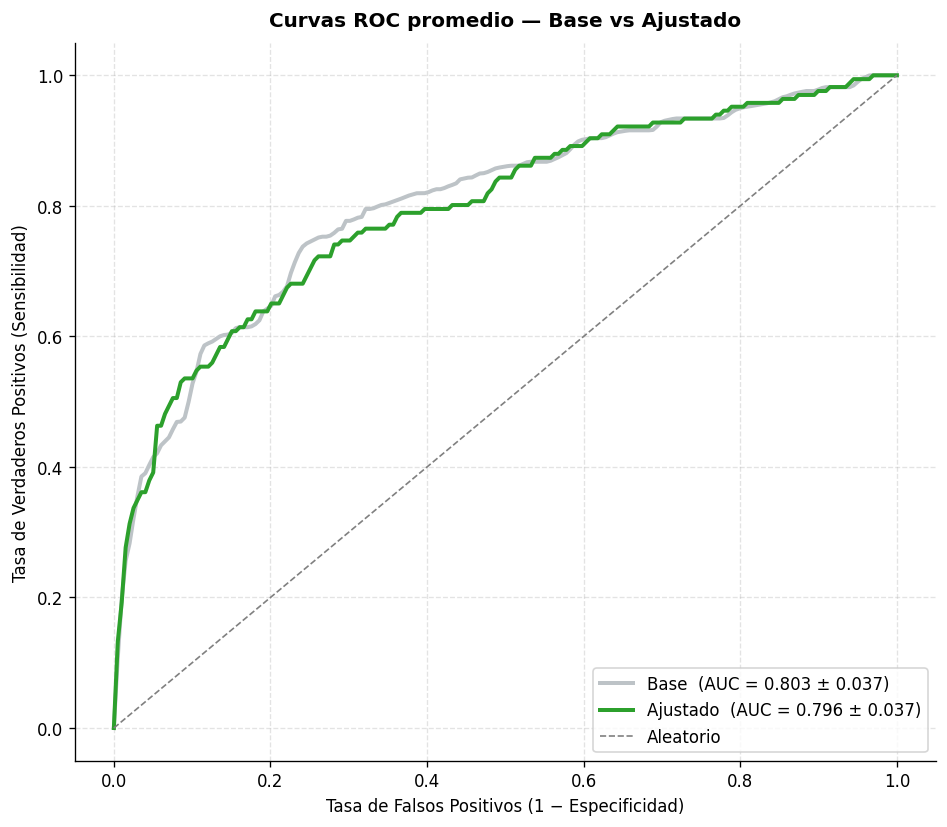

In [23]:
def roc_promedio(modelo, X, y, cv):
    """Devuelve fpr_mean, tpr_mean, tpr_std, auc_mean, auc_std."""
    mean_fpr = np.linspace(0, 1, 200)
    tprs, aucs = [], []
    for idx_tr, idx_va in cv.split(X, y):
        Xtr, Xva = X.iloc[idx_tr], X.iloc[idx_va]
        ytr, yva = y.iloc[idx_tr], y.iloc[idx_va]
        modelo.fit(Xtr, ytr)
        ysc = modelo.predict_proba(Xva)[:, 1]
        fpr, tpr, _ = roc_curve(yva, ysc)
        itpr = np.interp(mean_fpr, fpr, tpr); itpr[0] = 0
        tprs.append(itpr)
        aucs.append(roc_auc_score(yva, ysc))
    mean_tpr = np.mean(tprs, axis=0); mean_tpr[-1] = 1.0
    return mean_fpr, mean_tpr, np.std(tprs, axis=0), np.mean(aucs), np.std(aucs)

fpr_b, tpr_b, _, auc_b, sauc_b = roc_promedio(modelo_base, X_train, y_train, skf)
fpr_t, tpr_t, _, auc_t, sauc_t = roc_promedio(modelo_tuned, X_train, y_train, skf)

fig, ax = plt.subplots(figsize=(8, 7))
ax.plot(fpr_b, tpr_b, color=COLOR_BASE, lw=2.4,
        label=f"Base  (AUC = {auc_b:.3f} ± {sauc_b:.3f})")
ax.plot(fpr_t, tpr_t, color=COLOR_TUNED, lw=2.4,
        label=f"Ajustado  (AUC = {auc_t:.3f} ± {sauc_t:.3f})")
ax.plot([0,1], [0,1], color="gray", ls="--", lw=1, label="Aleatorio")
ax.set_xlabel("Tasa de Falsos Positivos (1 − Especificidad)")
ax.set_ylabel("Tasa de Verdaderos Positivos (Sensibilidad)")
ax.set_title("Curvas ROC promedio — Base vs Ajustado", pad=10)
ax.legend(loc="lower right", frameon=True, fancybox=True)
ax.grid(ls="--", alpha=0.35)
plt.tight_layout()
plt.show()

# Reentrenamos el modelo ajustado sobre todo el train (el loop anterior lo dejó en un fold)
modelo_tuned.fit(X_train, y_train);

---
## 8. Ajuste del umbral de decisión $\tau$

### 8.1 Motivación

Hasta aquí, todas las predicciones se han hecho con el **umbral por defecto $\tau = 0.5$**: el modelo predice `Yes` cuando $\hat{p} \geq 0.5$. Pero nada obliga a usar ese valor:

$$\hat{y} = \begin{cases} 1 & \text{si } \hat{p} \geq \tau \\ 0 & \text{si } \hat{p} < \tau \end{cases}$$

Al barrer $\tau$ se construye la curva Precision-Recall: bajar $\tau$ aumenta el Recall a costa de la Precision, y viceversa. Buscamos dos umbrales útiles:

- **$\tau_{F1}$** — el que maximiza el F1 (mejor balance global).
- **$\tau_{\text{recall}}$** — el que maximiza el Recall **sujeto a Precision ≥ 0.40** (criterio del negocio: aceptamos algunos FP, pero no exagerar).


In [24]:
# Probabilidades out-of-fold sobre el TRAIN (sin tocar el TEST)
y_proba_cv = cross_val_predict(modelo_tuned, X_train, y_train,
                               cv=skf, method="predict_proba", n_jobs=-1)[:, 1]

# Curva Precision-Recall
prec_vals, rec_vals, thr_pr = precision_recall_curve(y_train, y_proba_cv)
# precision_recall_curve devuelve len = len(thr)+1; alineamos
prec_vals_t, rec_vals_t = prec_vals[:-1], rec_vals[:-1]

# F1 por umbral (evita división por cero)
denom = (prec_vals_t + rec_vals_t)
f1_vals = np.where(denom > 0, 2 * prec_vals_t * rec_vals_t / denom, 0.0)

idx_f1 = np.argmax(f1_vals)
tau_f1 = thr_pr[idx_f1]

# τ con Recall máximo sujeto a Precision ≥ 0.40
mask_prec_ok = prec_vals_t >= 0.40
if mask_prec_ok.any():
    idx_rec_restringido = np.argmax(np.where(mask_prec_ok, rec_vals_t, -1))
    tau_rec = thr_pr[idx_rec_restringido]
else:
    # si nunca se alcanza Precision 0.40, relajamos a la máxima Precision posible
    tau_rec = thr_pr[np.argmax(prec_vals_t)]
    idx_rec_restringido = np.argmax(prec_vals_t)

print(f"τ por defecto         : 0.500")
print(f"τ_F1 (max F1)         : {tau_f1:.3f}  →  Precision = {prec_vals_t[idx_f1]:.3f},  Recall = {rec_vals_t[idx_f1]:.3f},  F1 = {f1_vals[idx_f1]:.3f}")
print(f"τ_Recall (P ≥ 0.40)   : {tau_rec:.3f}  →  Precision = {prec_vals_t[idx_rec_restringido]:.3f},  Recall = {rec_vals_t[idx_rec_restringido]:.3f},  F1 = {f1_vals[idx_rec_restringido]:.3f}")

τ por defecto         : 0.500
τ_F1 (max F1)         : 0.495  →  Precision = 0.562,  Recall = 0.518,  F1 = 0.539
τ_Recall (P ≥ 0.40)   : 0.402  →  Precision = 0.400,  Recall = 0.639,  F1 = 0.492


### 8.2 Curva Precision-Recall con los umbrales destacados

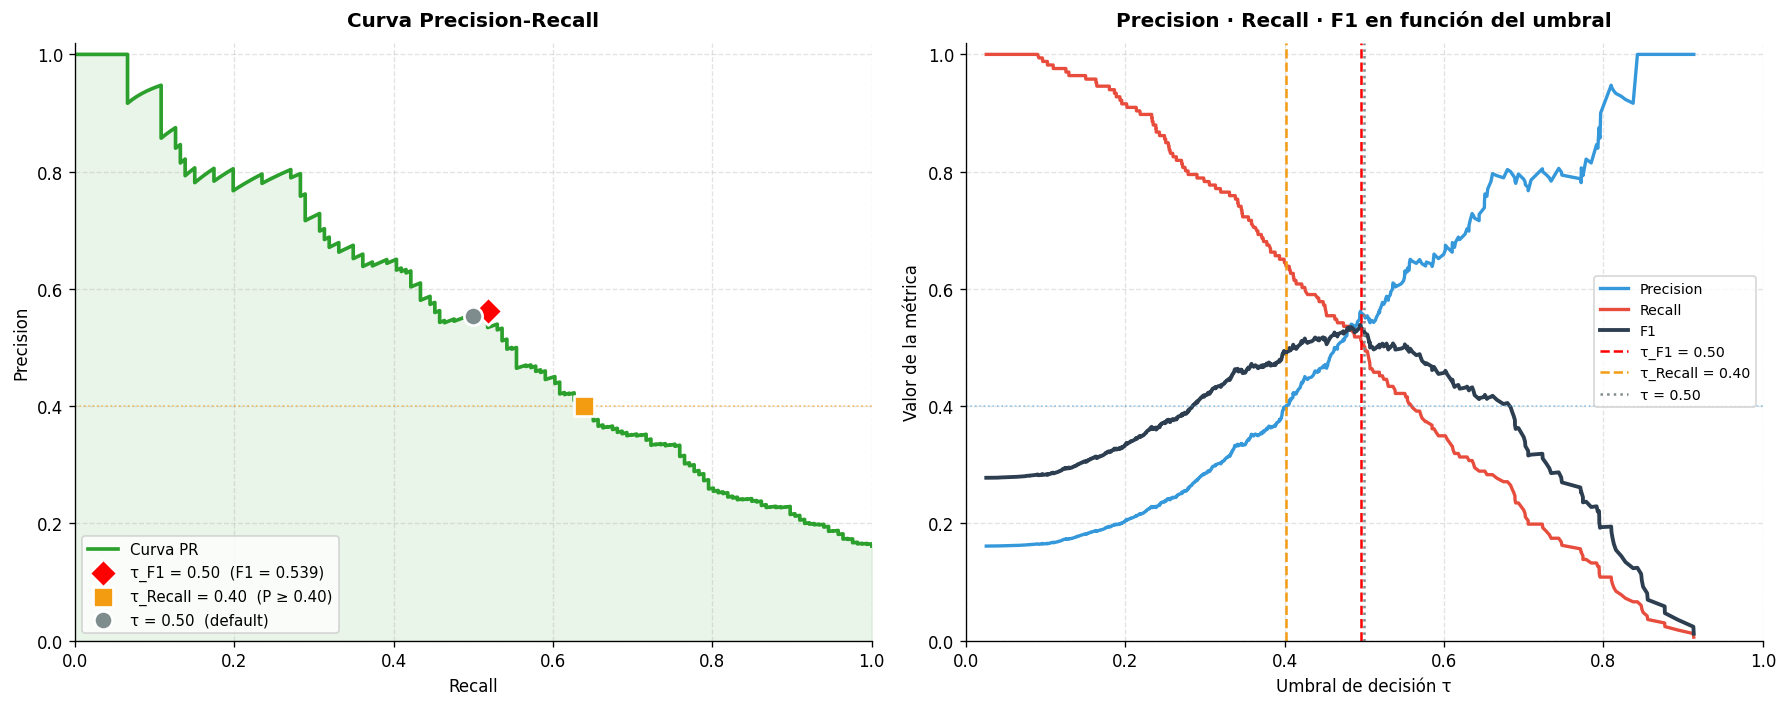

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── Panel A: Precision-Recall ─────────────────────────────────────────────
ax = axes[0]
ax.plot(rec_vals, prec_vals, color=COLOR_MODELO, lw=2.2, label="Curva PR")
ax.fill_between(rec_vals, prec_vals, alpha=0.10, color=COLOR_MODELO)

# Puntos destacados
ax.scatter(rec_vals_t[idx_f1], prec_vals_t[idx_f1],
           color="red", s=140, marker="D", edgecolor="white", linewidth=1.6,
           zorder=5, label=f"τ_F1 = {tau_f1:.2f}  (F1 = {f1_vals[idx_f1]:.3f})")
ax.scatter(rec_vals_t[idx_rec_restringido], prec_vals_t[idx_rec_restringido],
           color="#f39c12", s=140, marker="s", edgecolor="white", linewidth=1.6,
           zorder=5, label=f"τ_Recall = {tau_rec:.2f}  (P ≥ 0.40)")

# τ = 0.5
i05 = np.argmin(np.abs(thr_pr - 0.5))
ax.scatter(rec_vals_t[i05], prec_vals_t[i05],
           color="#7f8c8d", s=120, marker="o", edgecolor="white", linewidth=1.6,
           zorder=5, label=f"τ = 0.50  (default)")

ax.axhline(0.40, color="#f39c12", ls=":", lw=1, alpha=0.6)
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Curva Precision-Recall", pad=10)
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
ax.legend(loc="lower left", frameon=True, fancybox=True, fontsize=9)
ax.grid(ls="--", alpha=0.35)

# ── Panel B: Precision / Recall / F1 vs τ ─────────────────────────────────
ax = axes[1]
ax.plot(thr_pr, prec_vals_t, color="#3498db", lw=2, label="Precision")
ax.plot(thr_pr, rec_vals_t,  color="#e74c3c", lw=2, label="Recall")
ax.plot(thr_pr, f1_vals,     color="#2c3e50", lw=2.3, label="F1")

ax.axvline(tau_f1,  color="red",      ls="--", lw=1.5, label=f"τ_F1 = {tau_f1:.2f}")
ax.axvline(tau_rec, color="#f39c12",  ls="--", lw=1.5, label=f"τ_Recall = {tau_rec:.2f}")
ax.axvline(0.5,     color="#7f8c8d",  ls=":",  lw=1.5, label="τ = 0.50")
ax.axhline(0.40,    color="#3498db",  ls=":",  lw=1, alpha=0.5)

ax.set_xlabel("Umbral de decisión τ")
ax.set_ylabel("Valor de la métrica")
ax.set_title("Precision · Recall · F1 en función del umbral", pad=10)
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
ax.legend(loc="center right", frameon=True, fancybox=True, fontsize=8.5)
ax.grid(ls="--", alpha=0.35)

plt.tight_layout()
plt.show()

### 8.3 Matrices de Confusión a los tres umbrales

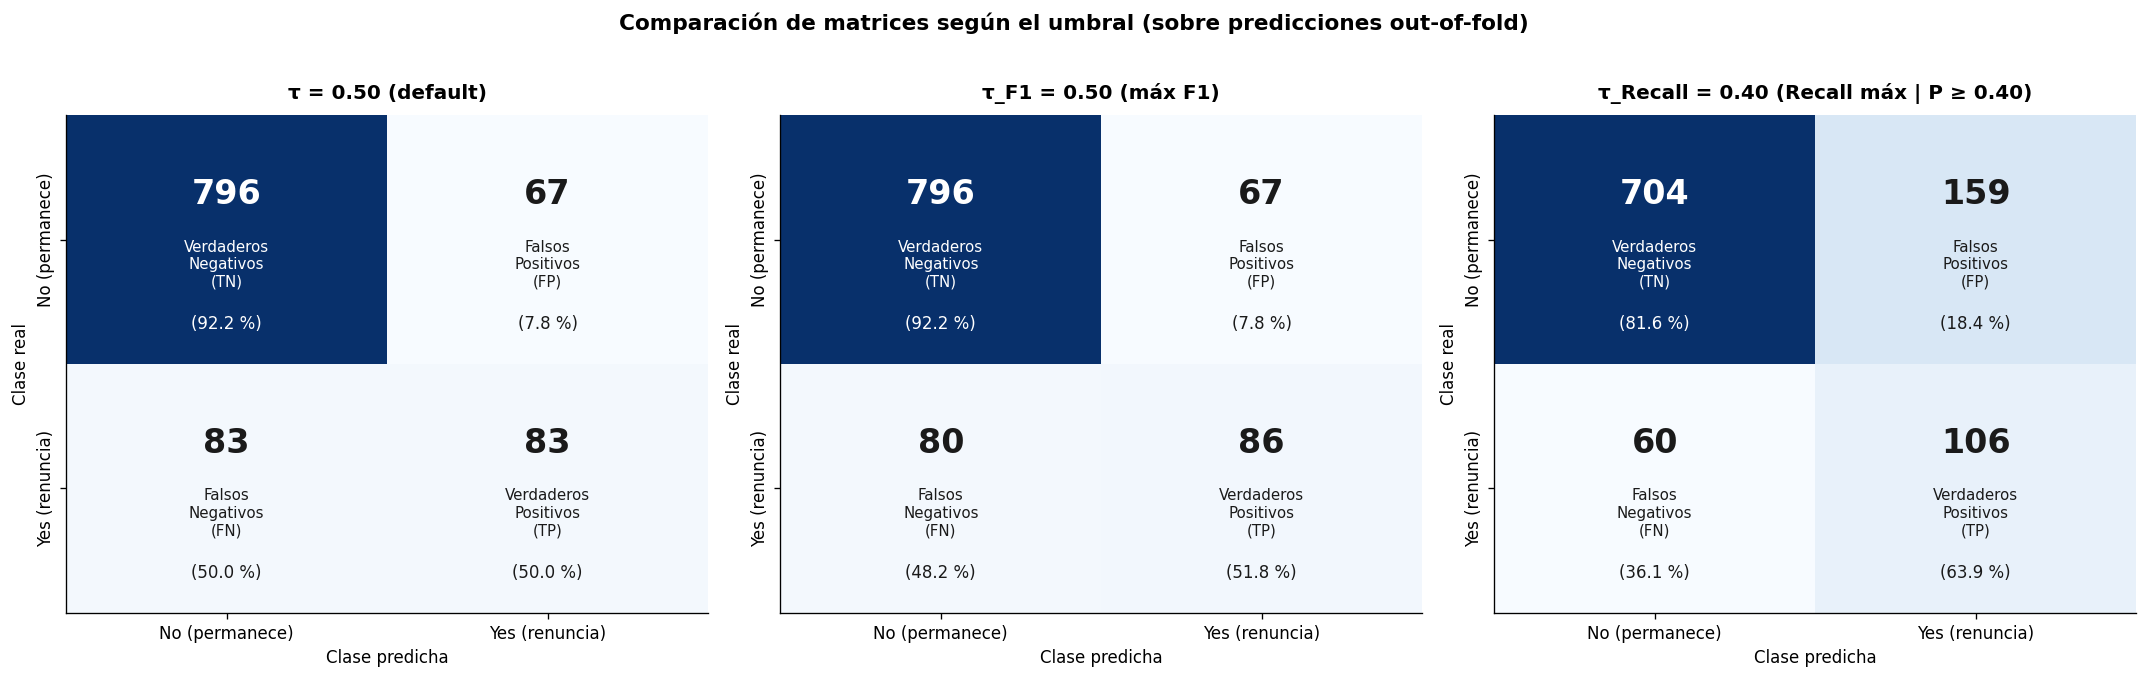

,τ,Accuracy,Precision,Recall,F1
Umbral,,,,,
τ = 0.50 (default),0.500,0.8542,0.5533,0.5000,0.5253
τ_F1 (máx F1),0.495,0.8571,0.5621,0.5181,0.5392
τ_Recall (P ≥ 0.40),0.402,0.7872,0.4000,0.6386,0.4919


In [26]:
def metricas_a_threshold(y_true, y_proba, tau):
    y_pred = (y_proba >= tau).astype(int)
    return y_pred, confusion_matrix(y_true, y_pred, labels=[0,1])

y_pred_05,   cm_05   = metricas_a_threshold(y_train, y_proba_cv, 0.50)
y_pred_f1,   cm_f1   = metricas_a_threshold(y_train, y_proba_cv, tau_f1)
y_pred_rec,  cm_rec  = metricas_a_threshold(y_train, y_proba_cv, tau_rec)

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
plot_cm(cm_05,  f"τ = 0.50 (default)",                    ax=axes[0])
plot_cm(cm_f1,  f"τ_F1 = {tau_f1:.2f} (máx F1)",          ax=axes[1])
plot_cm(cm_rec, f"τ_Recall = {tau_rec:.2f} (Recall máx | P ≥ 0.40)", ax=axes[2])
fig.suptitle("Comparación de matrices según el umbral (sobre predicciones out-of-fold)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# Tabla resumen por umbral
filas = []
for nombre, ypred, tau in [("τ = 0.50 (default)", y_pred_05, 0.50),
                            ("τ_F1 (máx F1)", y_pred_f1, tau_f1),
                            ("τ_Recall (P ≥ 0.40)", y_pred_rec, tau_rec)]:
    filas.append({
        "Umbral"   : nombre,
        "τ"        : round(tau, 3),
        "Accuracy" : accuracy_score(y_train, ypred),
        "Precision": precision_score(y_train, ypred),
        "Recall"   : recall_score(y_train, ypred),
        "F1"       : f1_score(y_train, ypred),
    })
pd.DataFrame(filas).set_index("Umbral").round(4)

---
## 9. Importancia de Variables

En Random Forest la importancia se calcula como el **promedio sobre todos los árboles** de la reducción de impureza (Gini por defecto) ponderada por la proporción de muestras que pasan por cada nodo. 

Las importancias suman 1; cada valor representa la **fracción del poder predictivo** atribuida a cada variable a lo largo del ensamble.

> **A diferencia de la Regresión Logística, las importancias de los modelos basados en árboles no tienen signo** — miden cuánto contribuye la variable a las decisiones, pero no en qué dirección. Para conocer el sentido del efecto hay que combinarla con un análisis univariado (ver `0b.Correlaciones_Target.ipynb`).


In [27]:
nombres_features = (modelo_tuned.named_steps["preprocesamiento"]
                                  .get_feature_names_out())
importancias = modelo_tuned.named_steps["clf"].feature_importances_

df_imp = pd.DataFrame({
    "Variable"   : nombres_features,
    "Importancia": importancias,
    "Importancia (%)": importancias * 100,
}).sort_values("Importancia", ascending=False).reset_index(drop=True)

print(f"Suma de importancias: {df_imp['Importancia'].sum():.4f}  (debe ser ≈ 1)")
print(f"Variables con importancia exactamente 0 (no usadas en el modelo):"
      f" {(df_imp['Importancia']==0).sum()} de {len(df_imp)}\n")

df_imp.head(20).round(4)

Suma de importancias: 1.0000  (debe ser ≈ 1)
Variables con importancia exactamente 0 (no usadas en el modelo): 0 de 44



,Variable,Importancia,Importancia (%)
0,MonthlyIncome,0.0847,8.4740
1,OverTime_Yes,0.0700,6.9968
2,Age,0.0642,6.4243
3,YearsAtCompany,0.0628,6.2769
4,YearsWithCurrManager,0.0604,6.0379
5,TotalWorkingYears,0.0514,5.1422
6,StockOptionLevel,0.0506,5.0577
7,NumCompaniesWorked,0.0410,4.1034
8,DailyRate,0.0394,3.9379
9,MonthlyRate,0.0349,3.4877


### 9.1 Top-15 variables más importantes

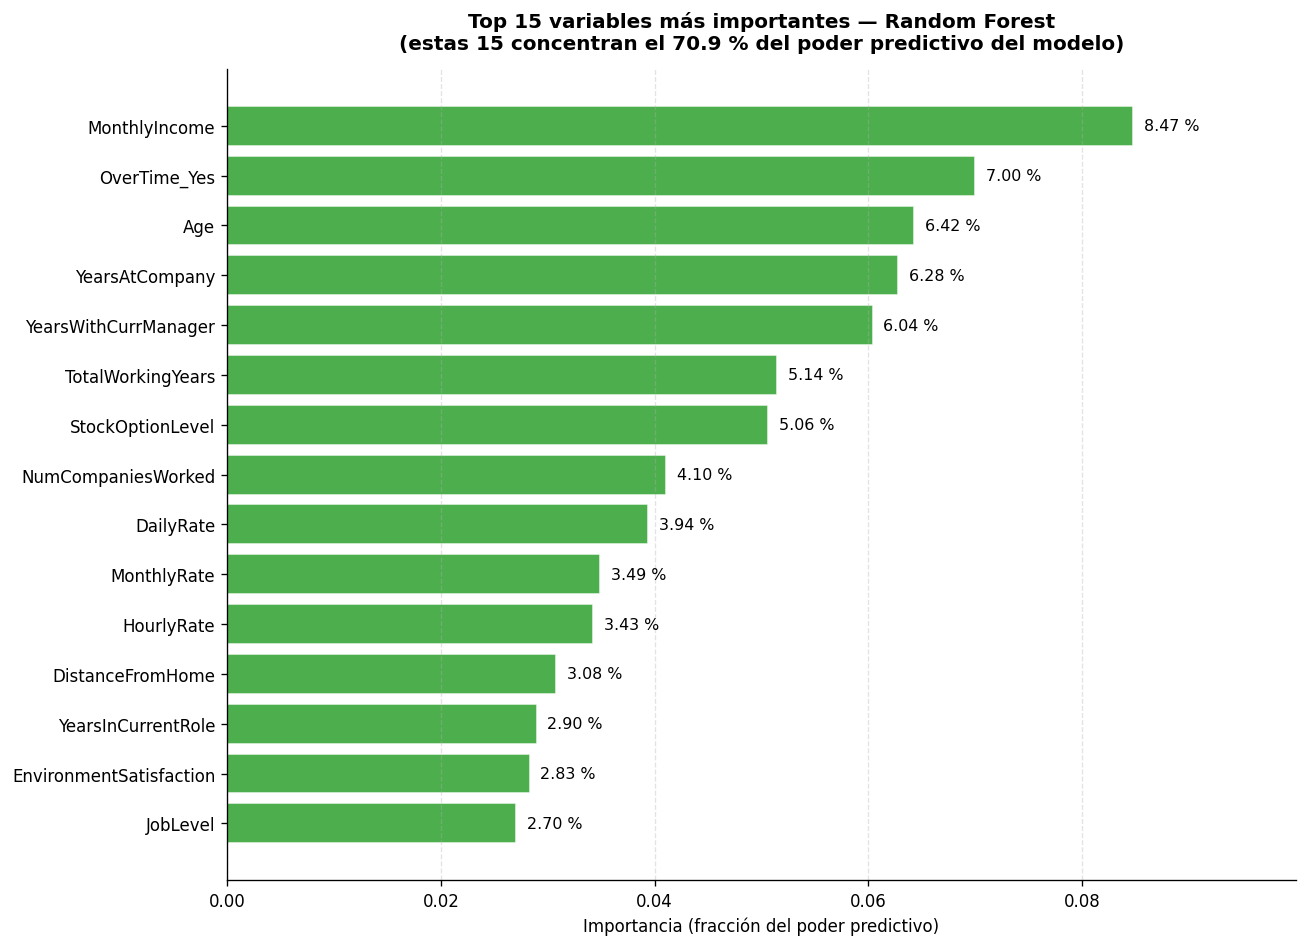

In [28]:
top_n = 15
df_top = df_imp.head(top_n).copy()
df_top = df_top.sort_values("Importancia")  # de menor a mayor para barh

NOMBRE_MODELO = "Random Forest"

fig, ax = plt.subplots(figsize=(11, 8))
bars = ax.barh(df_top["Variable"], df_top["Importancia"],
               color=COLOR_MODELO, edgecolor="white", alpha=0.85)

for b, v in zip(bars, df_top["Importancia"]):
    ax.text(v + df_top["Importancia"].max() * 0.012,
            b.get_y() + b.get_height()/2,
            f"{v*100:.2f} %", va="center", fontsize=9.5)

# Importancia acumulada del top-N
acumulada = df_top["Importancia"].sum() * 100
ax.set_xlabel("Importancia (fracción del poder predictivo)")
ax.set_title(f"Top {top_n} variables más importantes — {NOMBRE_MODELO}\n"
             f"(estas {top_n} concentran el {acumulada:.1f} % del poder predictivo del modelo)",
             fontsize=12, pad=12)

# Margen para las etiquetas
ax.set_xlim(0, df_top["Importancia"].max() * 1.18)
ax.grid(axis="x", ls="--", alpha=0.35)
plt.tight_layout()
plt.show()

### 9.2 Importancia acumulada

  19 variables → 80 % del poder predictivo
  26 variables → 90 % del poder predictivo
  31 variables → 95 % del poder predictivo
  44 variables → 100 % (total)


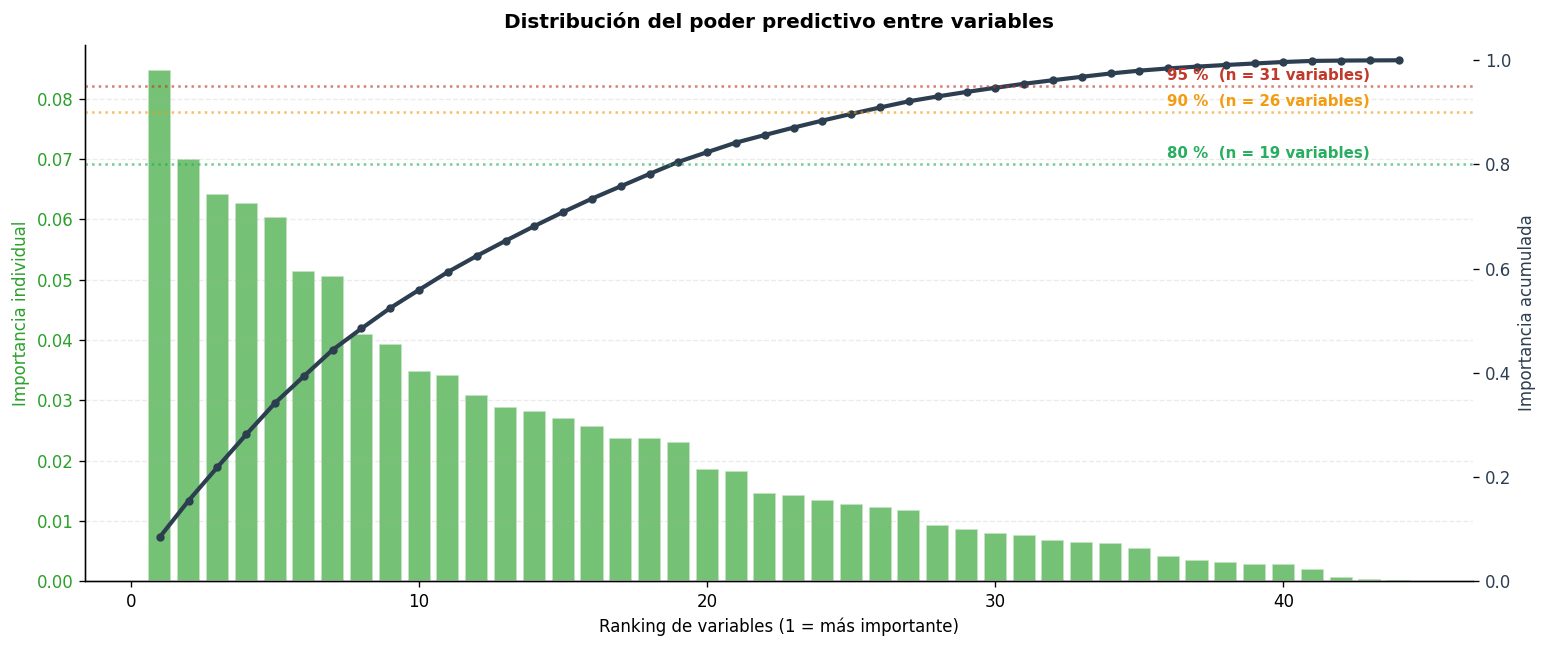

In [29]:
# ¿Cuántas variables concentran el 80 % / 90 % del poder predictivo?
df_imp_ord = df_imp.sort_values("Importancia", ascending=False).reset_index(drop=True)
df_imp_ord["Acumulada"] = df_imp_ord["Importancia"].cumsum()

n_80 = (df_imp_ord["Acumulada"] >= 0.80).idxmax() + 1
n_90 = (df_imp_ord["Acumulada"] >= 0.90).idxmax() + 1
n_95 = (df_imp_ord["Acumulada"] >= 0.95).idxmax() + 1

fig, ax = plt.subplots(figsize=(13, 5.5))

x = np.arange(1, len(df_imp_ord) + 1)
ax.bar(x, df_imp_ord["Importancia"], color=COLOR_MODELO, edgecolor="white",
       alpha=0.65, label="Importancia individual")
ax2 = ax.twinx()
ax2.plot(x, df_imp_ord["Acumulada"], color="#2c3e50", lw=2.5,
         marker="o", markersize=4, label="Importancia acumulada")

for pct, n, c in [(0.80, n_80, "#27ae60"),
                  (0.90, n_90, "#f39c12"),
                  (0.95, n_95, "#c0392b")]:
    ax2.axhline(pct, color=c, ls=":", lw=1.5, alpha=0.65)
    ax2.text(len(x) - 1, pct + 0.012, f"{int(pct*100)} %  (n = {n} variables)",
             ha="right", fontsize=9, color=c, fontweight="bold")

ax.set_xlabel("Ranking de variables (1 = más importante)")
ax.set_ylabel("Importancia individual", color=COLOR_MODELO)
ax2.set_ylabel("Importancia acumulada", color="#2c3e50")
ax2.set_ylim(0, 1.03)
ax.tick_params(axis="y", labelcolor=COLOR_MODELO)
ax2.tick_params(axis="y", labelcolor="#2c3e50")
ax.set_title("Distribución del poder predictivo entre variables", fontsize=12, pad=10)
ax.grid(axis="y", ls="--", alpha=0.25)

print(f"  {n_80:>2} variables → 80 % del poder predictivo")
print(f"  {n_90:>2} variables → 90 % del poder predictivo")
print(f"  {n_95:>2} variables → 95 % del poder predictivo")
print(f"  {len(df_imp_ord):>2} variables → 100 % (total)")

plt.tight_layout()
plt.show()

---
## 10. Persistencia de los resultados

Guardamos los scores de CV (base y tuned), el conjunto completo de resultados del search, y los umbrales óptimos, para que `5.Comparacion_Modelos.ipynb` los lea.


In [30]:
os.makedirs("cv_results", exist_ok=True)

cv_metrics = {
    "modelo"      : "Random Forest",
    "metricas_base": {
        m: {"scores": cv_base[f"test_{m}"].tolist(),
             "mu"    : float(cv_base[f"test_{m}"].mean()),
             "sigma" : float(cv_base[f"test_{m}"].std())}
        for m in scoring
    },
    "metricas_tuned": {
        m: {"scores": cv_tuned[f"test_{m}"].tolist(),
             "mu"    : float(cv_tuned[f"test_{m}"].mean()),
             "sigma" : float(cv_tuned[f"test_{m}"].std())}
        for m in scoring
    },
    "best_params" : {k: (v if isinstance(v, (int, float, str, bool, type(None)))
                          else str(v)) for k, v in search.best_params_.items()},
    "thresholds"  : {
        "tau_default" : 0.50,
        "tau_f1"      : float(tau_f1),
        "tau_recall"  : float(tau_rec),
    },
}

out_path = os.path.join("cv_results", "random_forest.json")
with open(out_path, "w", encoding="utf-8") as f:
    json.dump(cv_metrics, f, indent=2, ensure_ascii=False)

print(f"Resultados guardados en: {out_path}")

Resultados guardados en: cv_results/random_forest.json


---
## 11. Síntesis del modelo Random Forest

**Modelo base (sin tuning):**

- Las métricas resumidas en la tabla 5.2 son la línea base contra la cual se mide el tuning.

**Tras `RandomizedSearchCV` (60 candidatos, métrica F1):**

- La tabla 7 muestra el cambio en cada métrica entre el modelo base y el ajustado.
- La gráfica 7.2 cuantifica la reducción del **gap Train − Validación**: una reducción significativa indica que la regularización aplicada por el tuning logró combatir el sobreajuste detectado en §5.

**Tras ajuste del umbral $\tau$:**

- $\tau = 0.50$ (default) es rara vez óptimo en problemas desbalanceados.
- $\tau_{F1}$ — el que mejor balancea Precision y Recall en este modelo.
- $\tau_{\text{recall}}$ — el que prioriza detectar renuncias manteniendo Precision ≥ 0.40 (criterio de negocio).

> La comparación final entre los cuatro modelos (cada uno con su mejor configuración) se realiza en `5.Comparacion_Modelos.ipynb`.
